<a href="https://www.kaggle.com/code/omborse771924/uci-nursery-data-set-eda?scriptVersionId=333560099" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/heitornunes/nursery/nursery.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/heitornunes/nursery/nursery.csv')

In [3]:
df.head()

,parents,has_nurs,form,children,housing,finance,social,health,final evaluation
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority


In [4]:
df.tail

<bound method NDFrame.tail of           parents   has_nurs      form children     housing     finance  \
0           usual     proper  complete        1  convenient  convenient   
1           usual     proper  complete        1  convenient  convenient   
2           usual     proper  complete        1  convenient  convenient   
3           usual     proper  complete        1  convenient  convenient   
4           usual     proper  complete        1  convenient  convenient   
...           ...        ...       ...      ...         ...         ...   
12955  great_pret  very_crit    foster     more    critical      inconv   
12956  great_pret  very_crit    foster     more    critical      inconv   
12957  great_pret  very_crit    foster     more    critical      inconv   
12958  great_pret  very_crit    foster     more    critical      inconv   
12959  great_pret  very_crit    foster     more    critical      inconv   

              social       health final evaluation  
0            non

In [5]:
df.info

<bound method DataFrame.info of           parents   has_nurs      form children     housing     finance  \
0           usual     proper  complete        1  convenient  convenient   
1           usual     proper  complete        1  convenient  convenient   
2           usual     proper  complete        1  convenient  convenient   
3           usual     proper  complete        1  convenient  convenient   
4           usual     proper  complete        1  convenient  convenient   
...           ...        ...       ...      ...         ...         ...   
12955  great_pret  very_crit    foster     more    critical      inconv   
12956  great_pret  very_crit    foster     more    critical      inconv   
12957  great_pret  very_crit    foster     more    critical      inconv   
12958  great_pret  very_crit    foster     more    critical      inconv   
12959  great_pret  very_crit    foster     more    critical      inconv   

              social       health final evaluation  
0            n

In [6]:
df.describe

<bound method NDFrame.describe of           parents   has_nurs      form children     housing     finance  \
0           usual     proper  complete        1  convenient  convenient   
1           usual     proper  complete        1  convenient  convenient   
2           usual     proper  complete        1  convenient  convenient   
3           usual     proper  complete        1  convenient  convenient   
4           usual     proper  complete        1  convenient  convenient   
...           ...        ...       ...      ...         ...         ...   
12955  great_pret  very_crit    foster     more    critical      inconv   
12956  great_pret  very_crit    foster     more    critical      inconv   
12957  great_pret  very_crit    foster     more    critical      inconv   
12958  great_pret  very_crit    foster     more    critical      inconv   
12959  great_pret  very_crit    foster     more    critical      inconv   

              social       health final evaluation  
0           

In [7]:
df.isnull

<bound method DataFrame.isnull of           parents   has_nurs      form children     housing     finance  \
0           usual     proper  complete        1  convenient  convenient   
1           usual     proper  complete        1  convenient  convenient   
2           usual     proper  complete        1  convenient  convenient   
3           usual     proper  complete        1  convenient  convenient   
4           usual     proper  complete        1  convenient  convenient   
...           ...        ...       ...      ...         ...         ...   
12955  great_pret  very_crit    foster     more    critical      inconv   
12956  great_pret  very_crit    foster     more    critical      inconv   
12957  great_pret  very_crit    foster     more    critical      inconv   
12958  great_pret  very_crit    foster     more    critical      inconv   
12959  great_pret  very_crit    foster     more    critical      inconv   

              social       health final evaluation  
0           

In [8]:
df.isnull().sum()

parents             0
has_nurs            0
form                0
children            0
housing             0
finance             0
social              0
health              0
final evaluation    0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
12955    False
12956    False
12957    False
12958    False
12959    False
Length: 12960, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['parents', 'has_nurs', 'form', 'children', 'housing', 'finance',
       'social', 'health', 'final evaluation'],
      dtype='object')

## EDA

Dataset Shape
(12960, 9)
Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12960 entries, 0 to 12959
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   parents           12960 non-null  object
 1   has_nurs          12960 non-null  object
 2   form              12960 non-null  object
 3   children          12960 non-null  object
 4   housing           12960 non-null  object
 5   finance           12960 non-null  object
 6   social            12960 non-null  object
 7   health            12960 non-null  object
 8   final evaluation  12960 non-null  object
dtypes: object(9)
memory usage: 911.4+ KB
None
Missing Values
parents             0
has_nurs            0
form                0
children            0
housing             0
finance             0
social              0
health              0
final evaluation    0
dtype: int64
Description
       parents has_nurs      form children     housing     fina

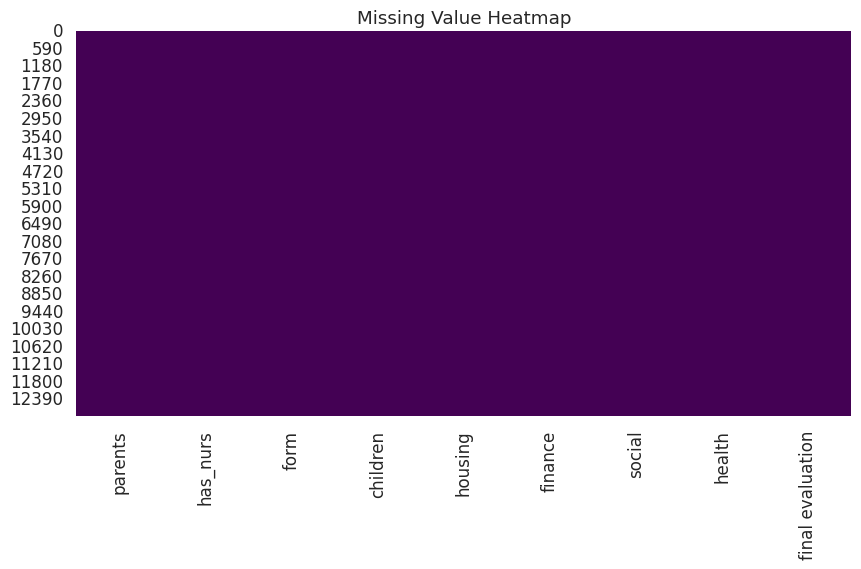

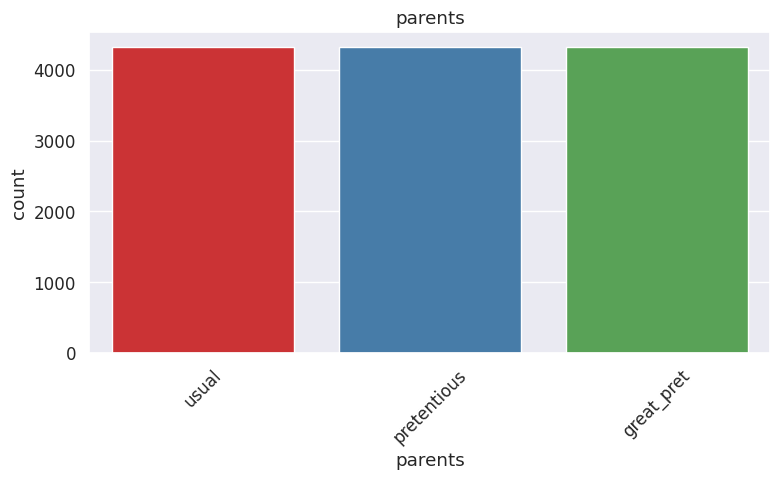

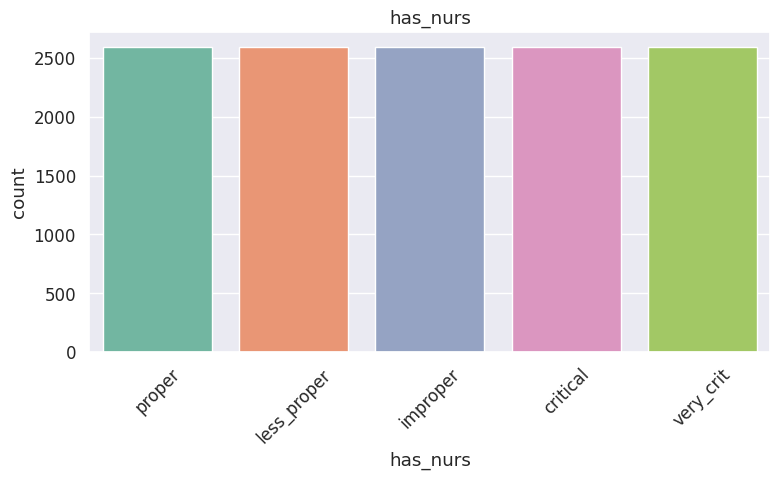

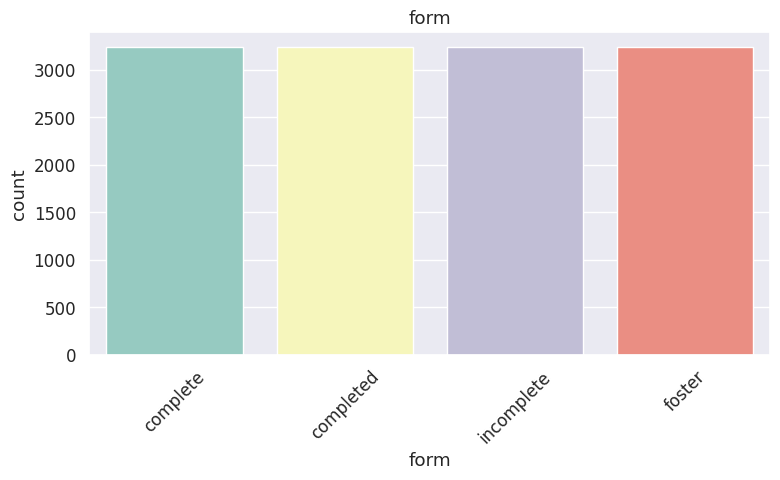

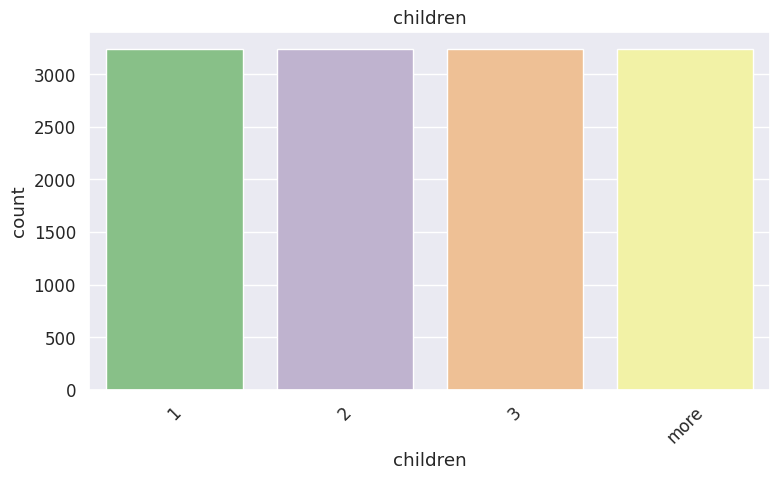

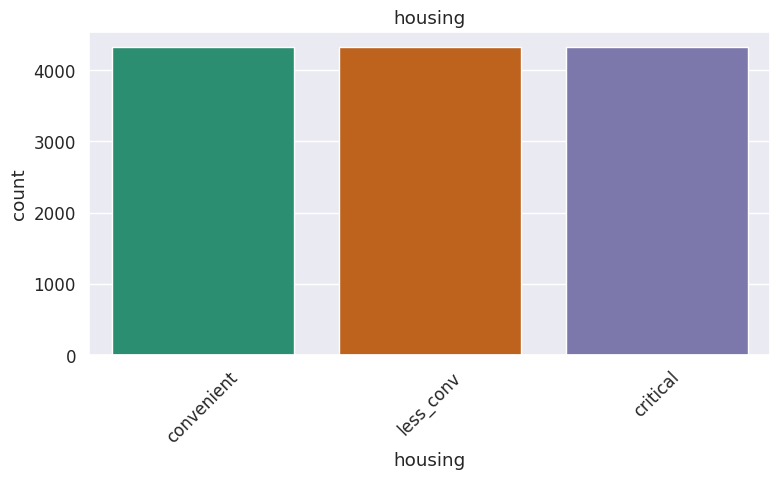

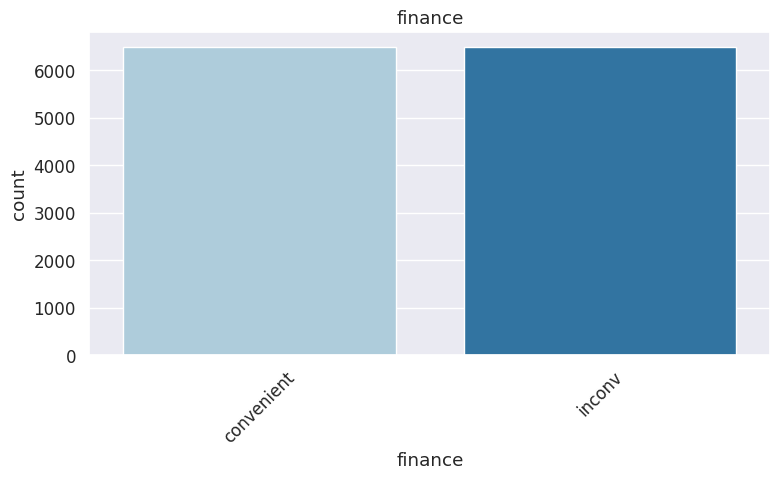

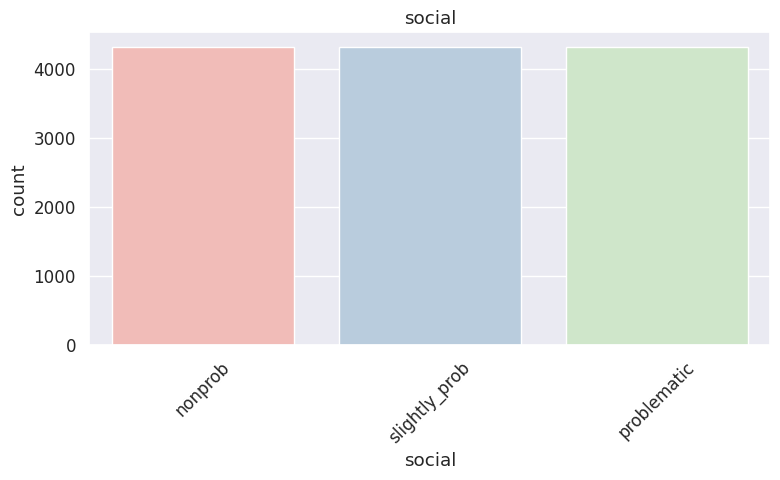

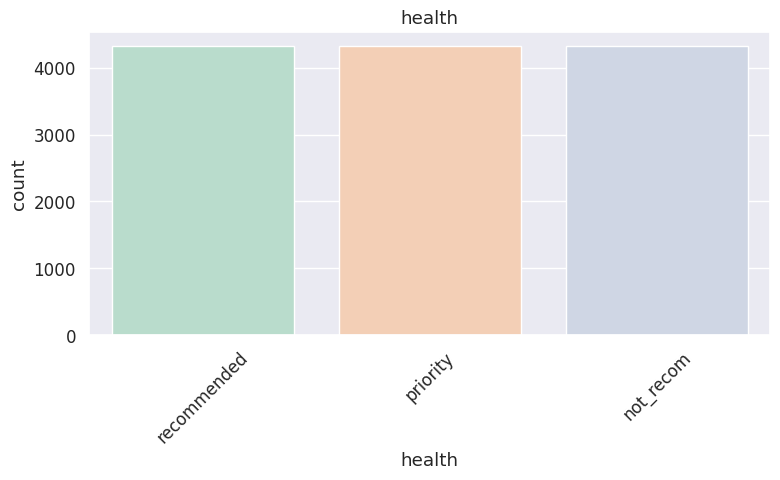

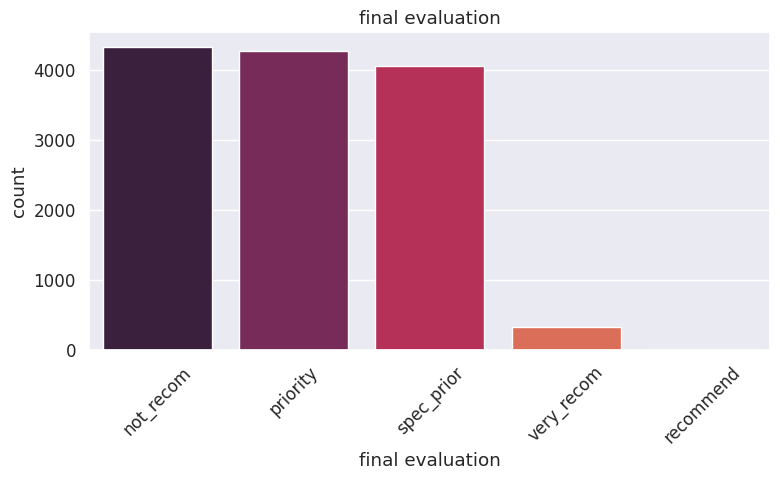

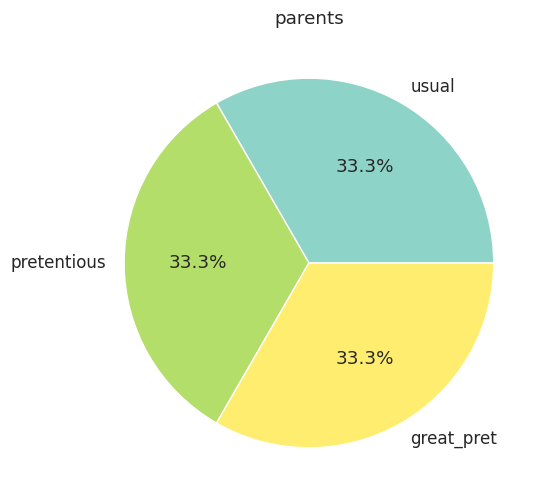

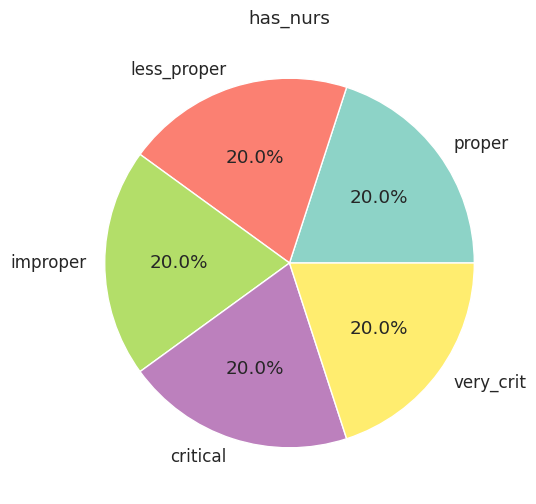

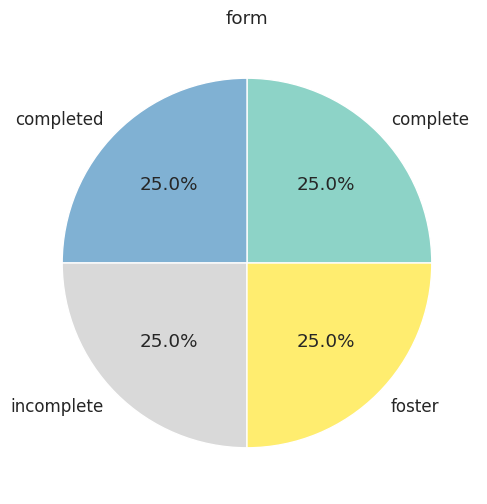

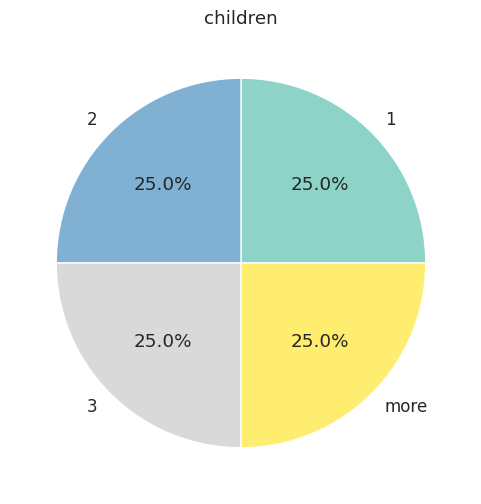

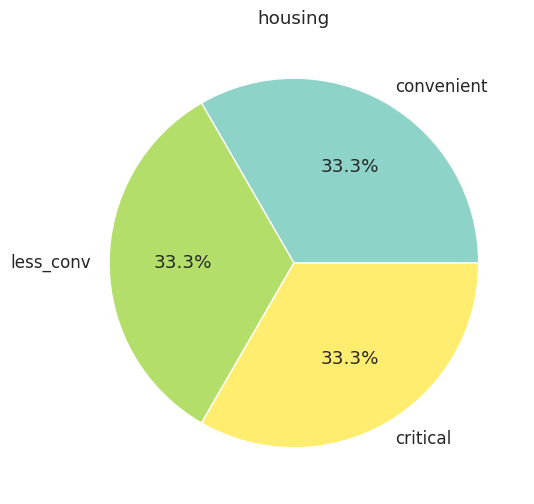

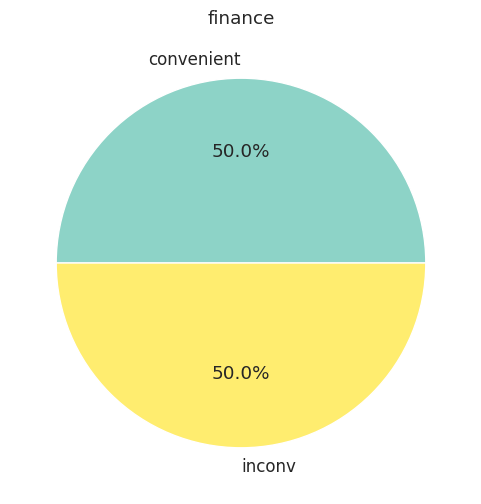

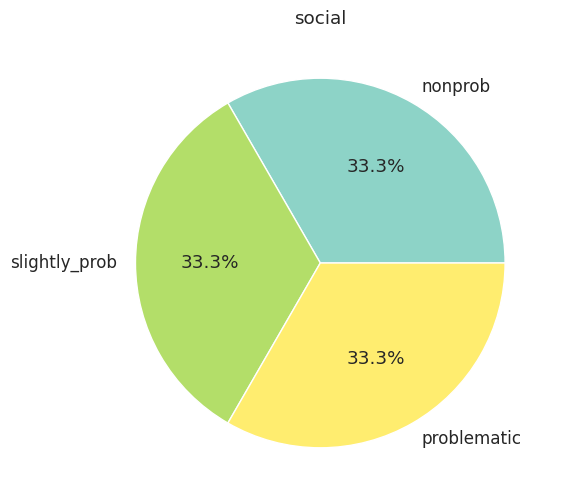

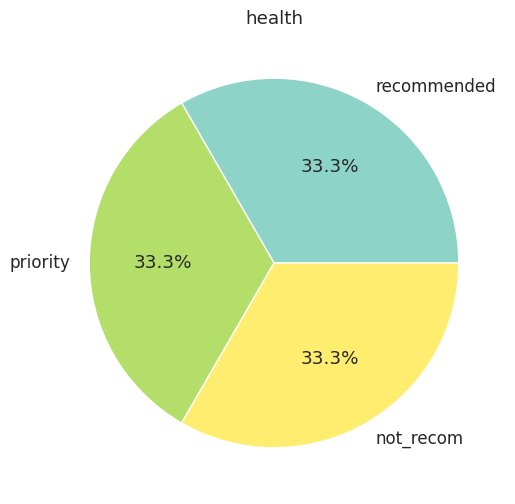

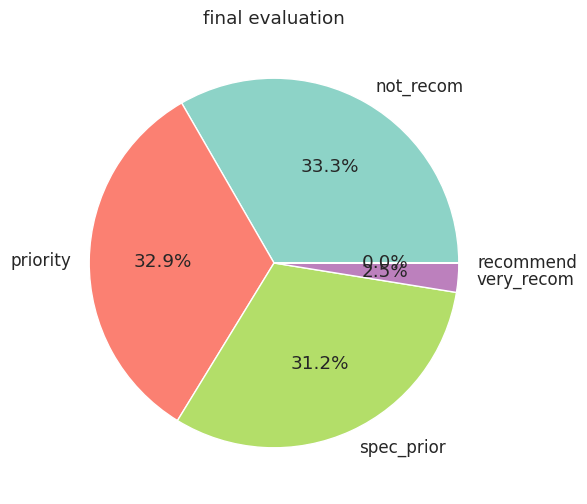

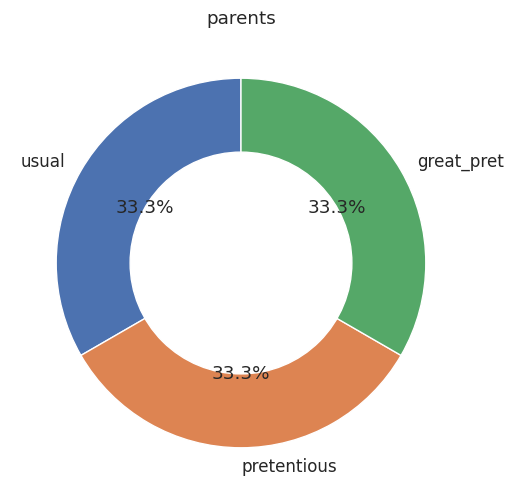

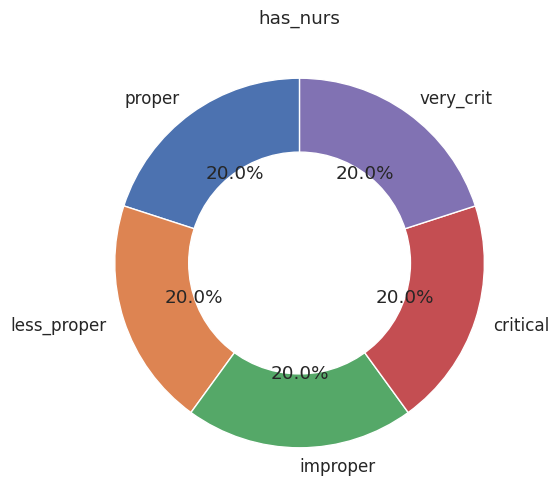

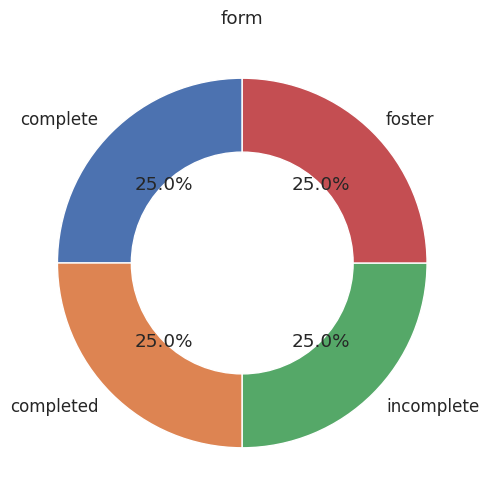

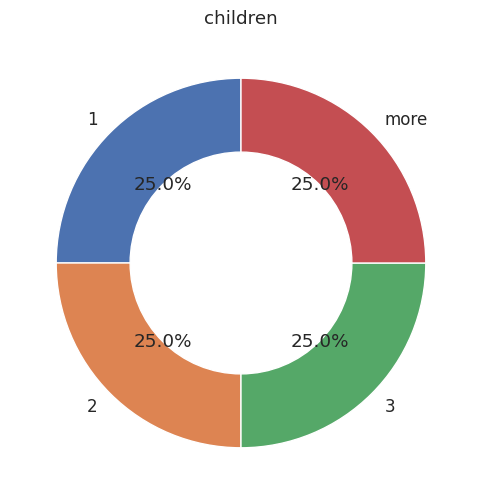

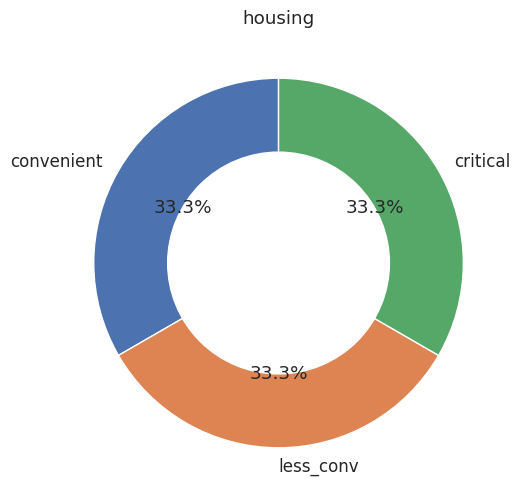

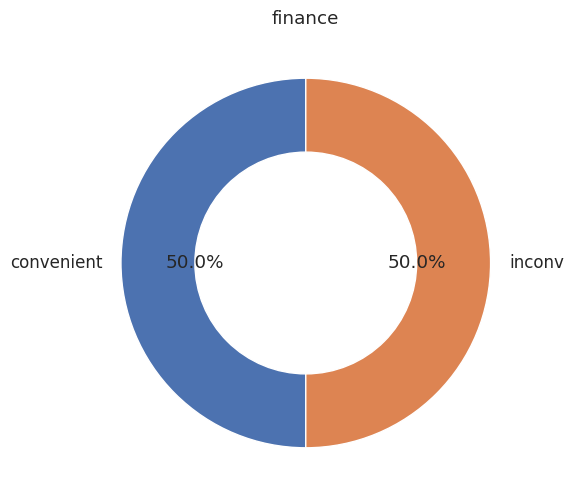

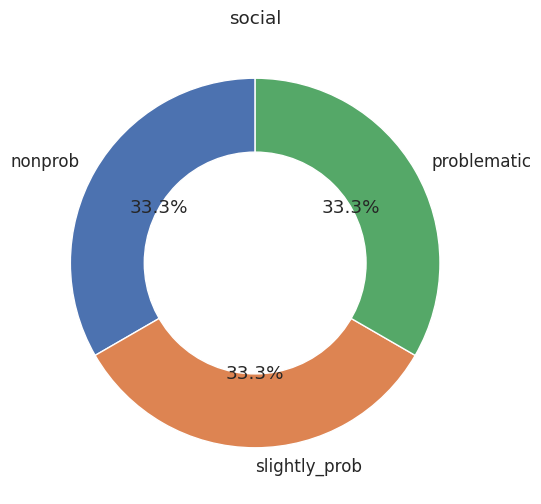

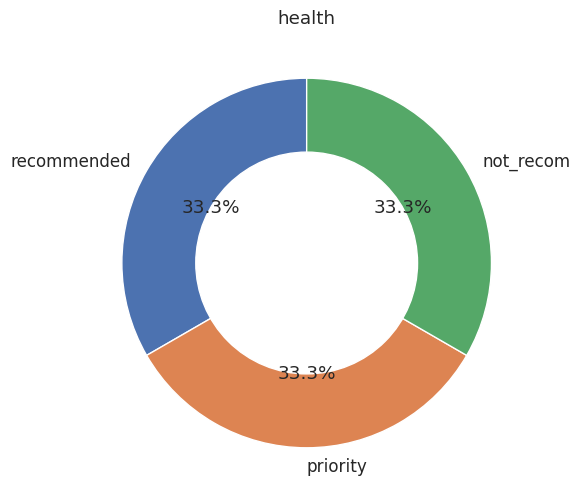

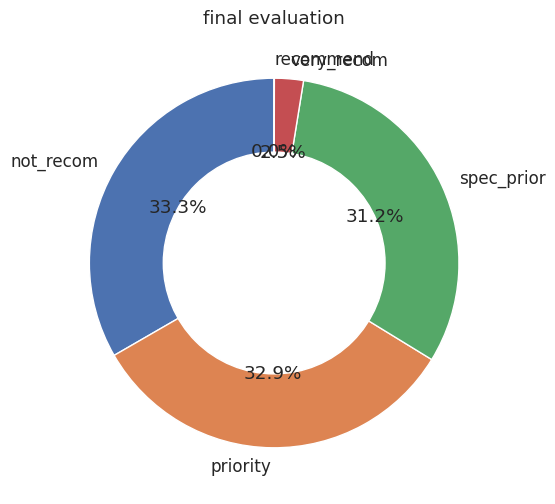

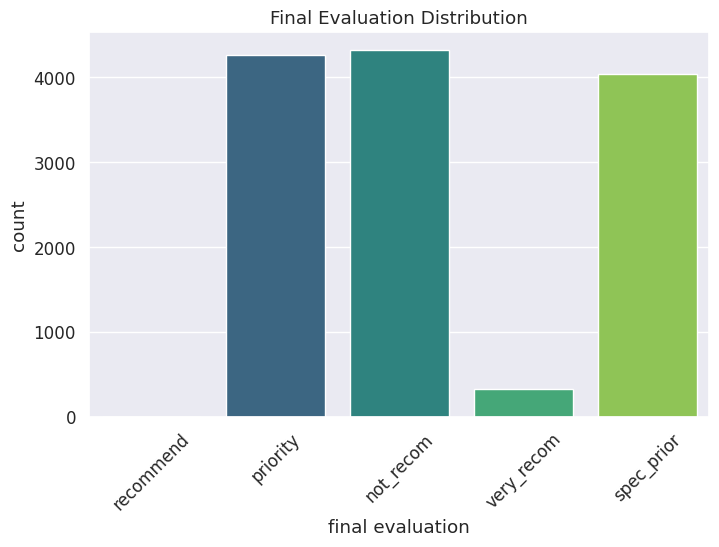

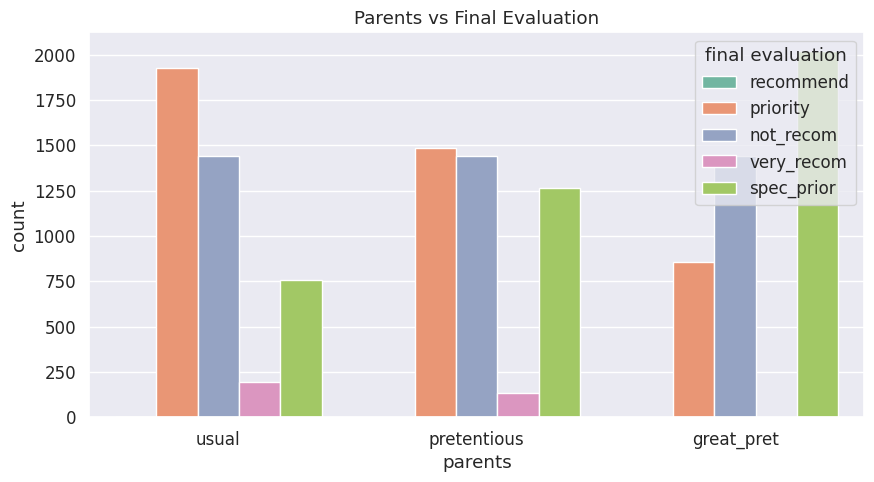

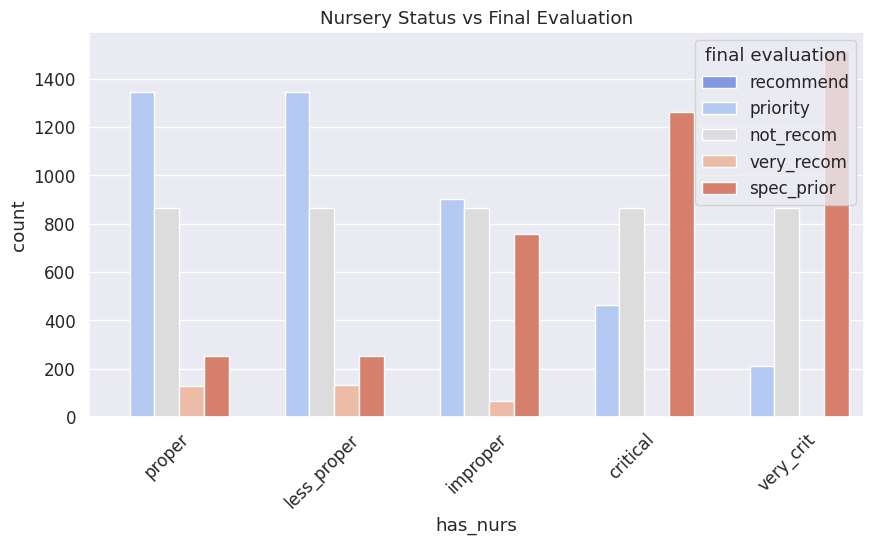

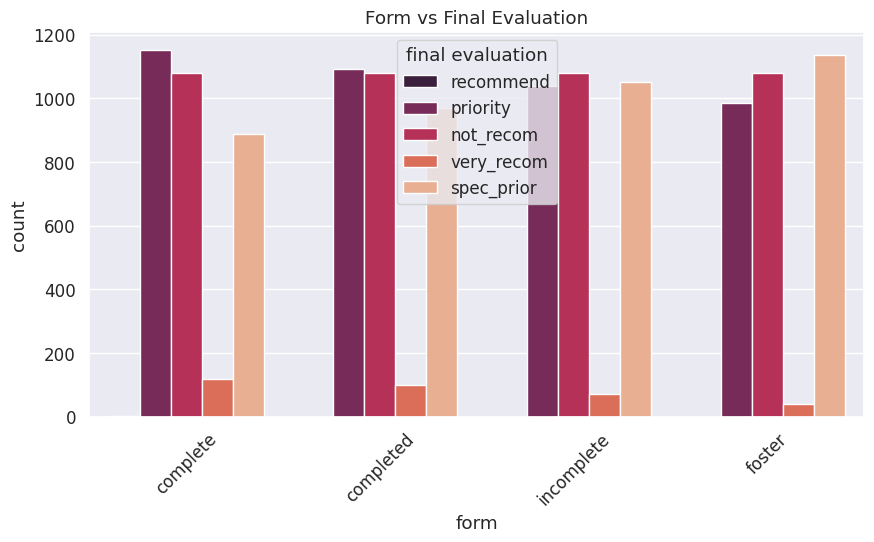

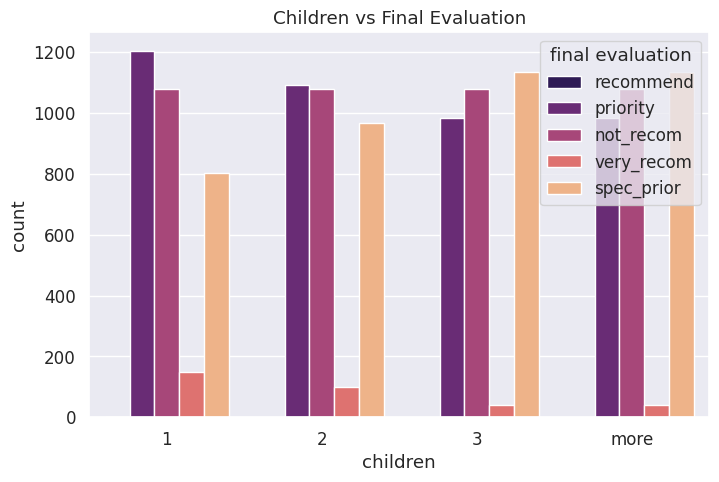

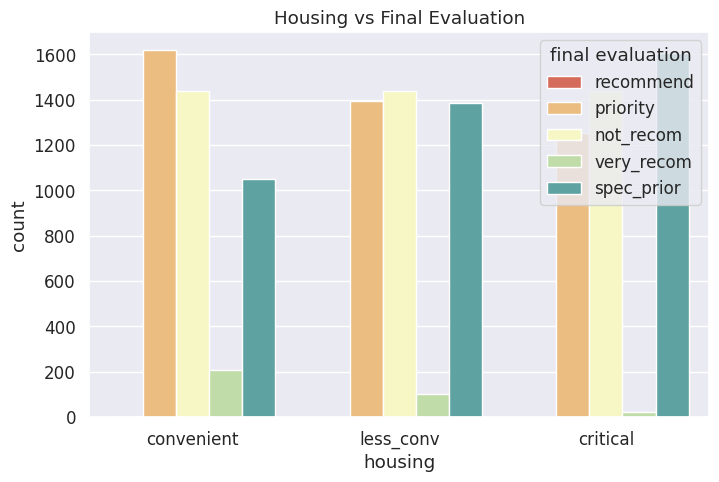

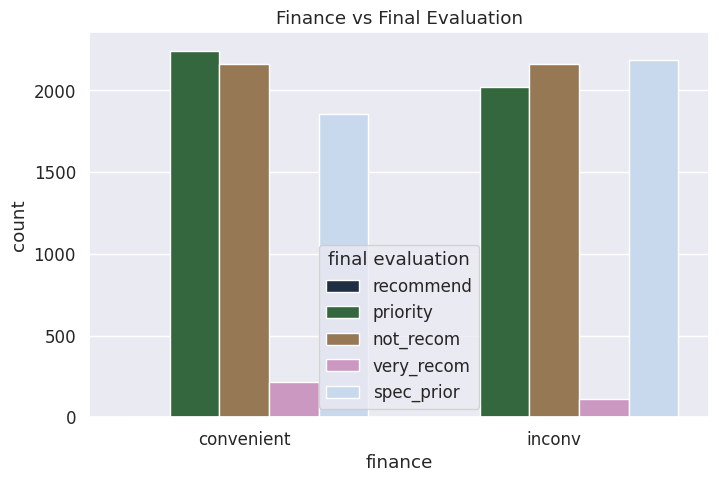

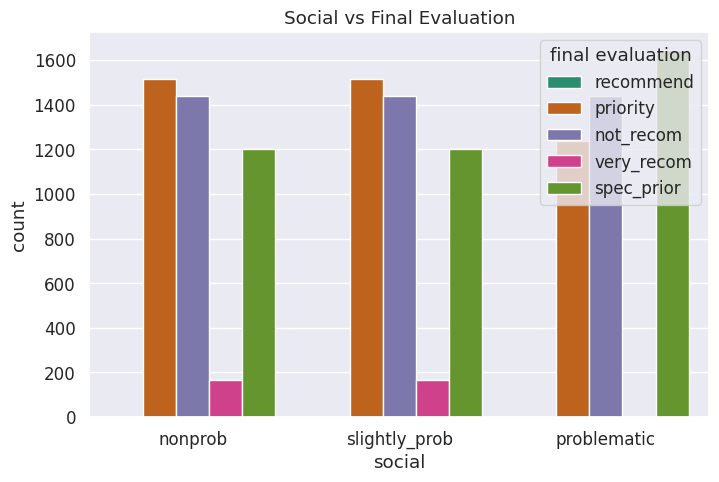

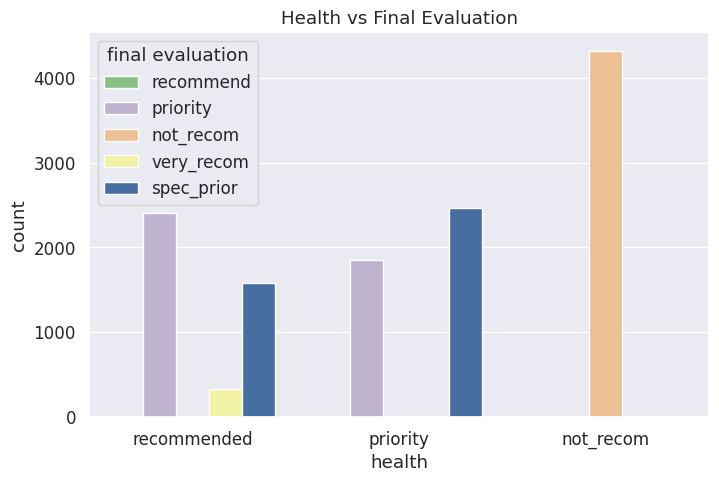

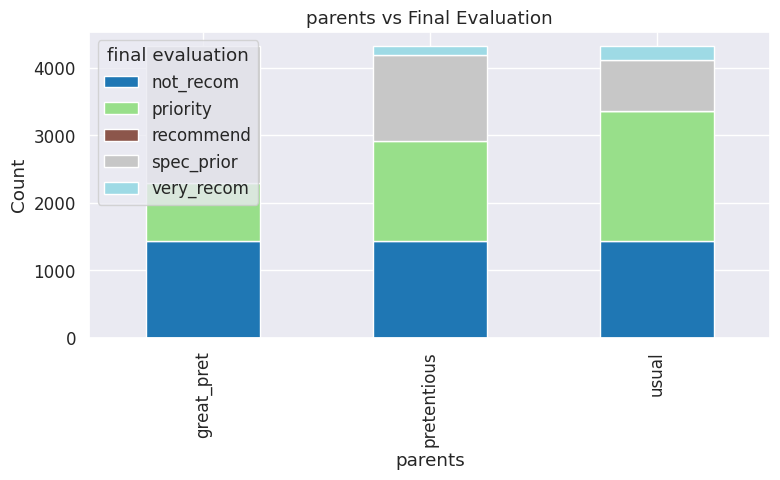

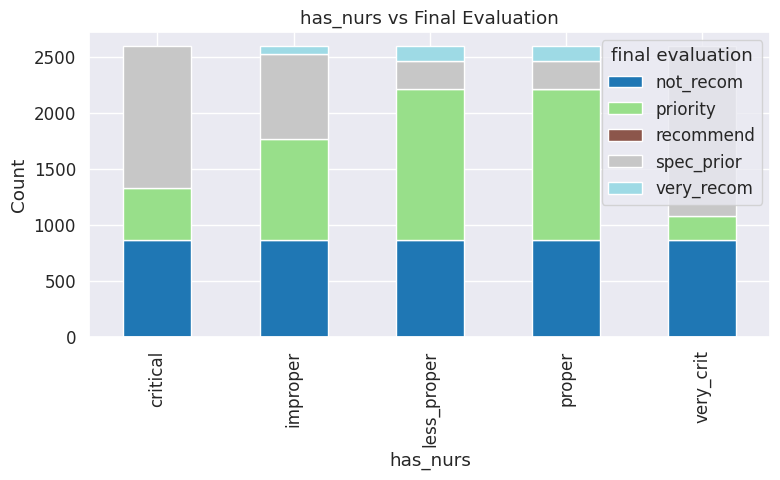

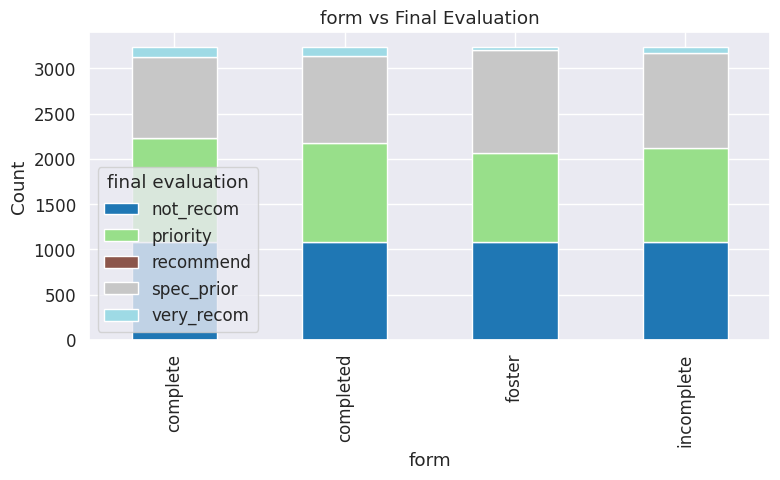

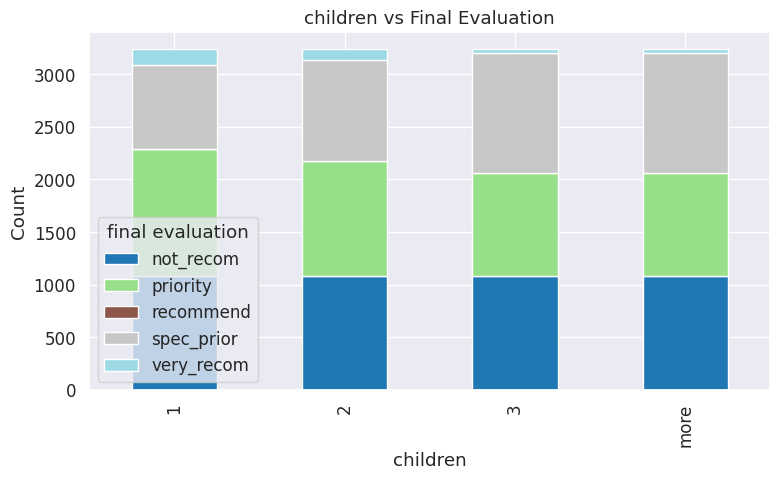

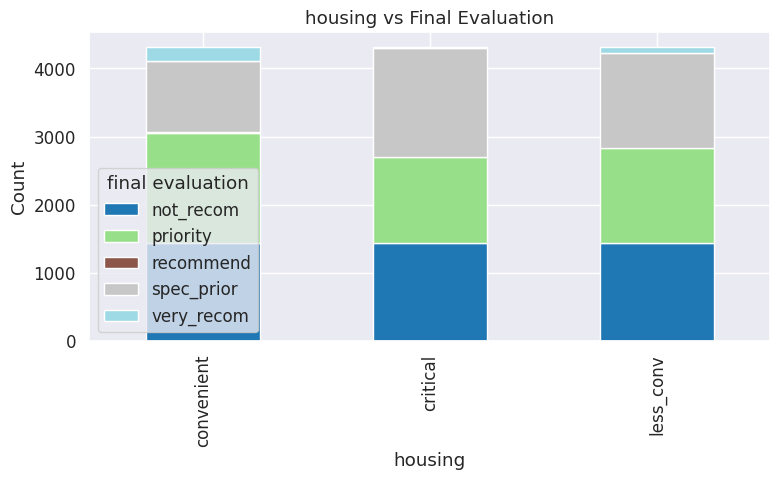

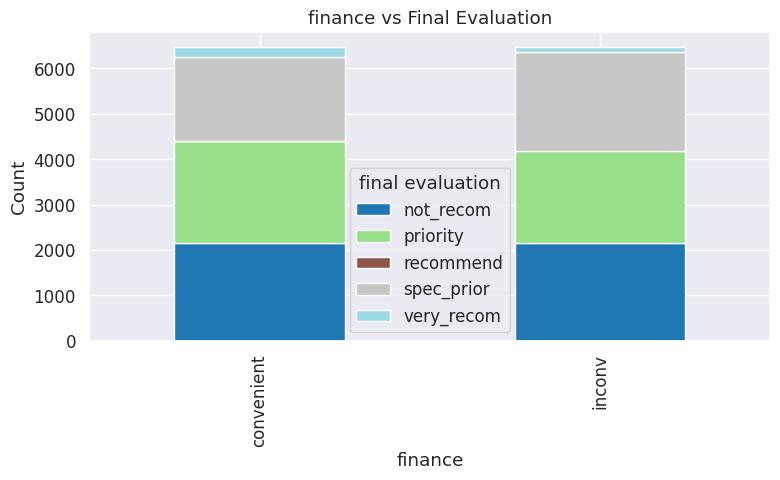

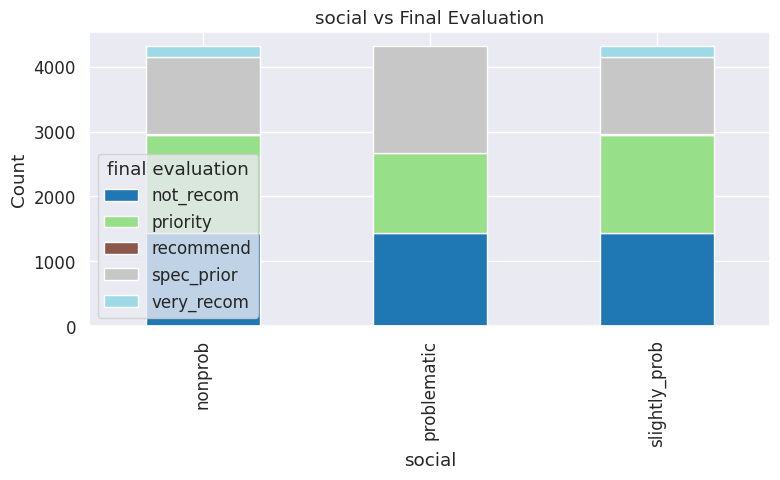

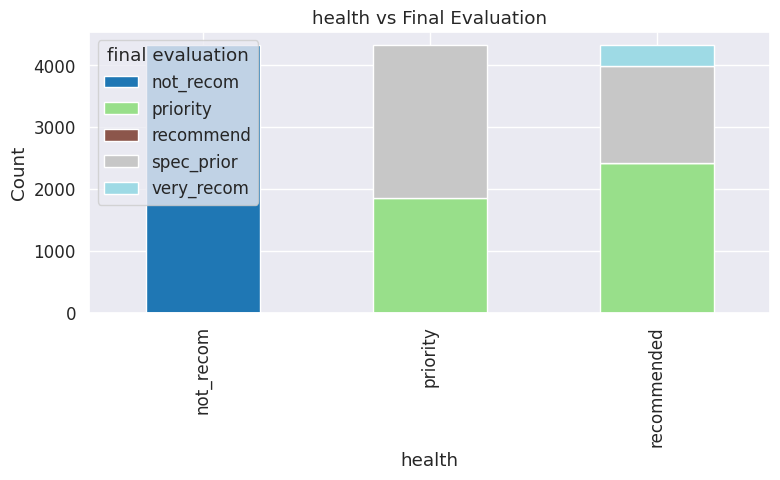

EDA COMPLETED SUCCESSFULLY


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================================================
# DATASET OVERVIEW
# ==========================================================

print("="*60)
print("Dataset Shape")
print(data.shape)

print("="*60)
print("Dataset Info")
print(data.info())

print("="*60)
print("Missing Values")
print(data.isnull().sum())

print("="*60)
print("Description")
print(data.describe(include='all'))

# ==========================================================
# MISSING VALUE HEATMAP
# ==========================================================

plt.figure(figsize=(10,5))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()

# ==========================================================
# COUNTPLOTS
# ==========================================================

palettes = [
"Set1","Set2","Set3","Accent",
"Dark2","Paired","Pastel1","Pastel2",
"rocket","mako","crest","flare",
"viridis","Spectral","coolwarm"
]

for i,col in enumerate(data.columns):

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=data,
        x=col,
        palette=palettes[i % len(palettes)],
        order=data[col].value_counts().index
    )

    plt.title(col)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

for col in data.columns:

    plt.figure(figsize=(6,6))

    data[col].value_counts().plot(
        kind="pie",
        autopct="%1.1f%%",
        cmap="Set3"
    )

    plt.ylabel("")

    plt.title(col)

    plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in data.columns:

    counts = data[col].value_counts()

    fig, ax = plt.subplots(figsize=(6,6))

    ax.pie(
        counts,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90
    )

    centre = plt.Circle((0,0),0.60,fc="white")

    fig.gca().add_artist(centre)

    plt.title(col)

    plt.show()

# ==========================================================
# FINAL EVALUATION DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="final evaluation",
    palette="viridis"
)

plt.title("Final Evaluation Distribution")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# PARENTS vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="parents",
    hue="final evaluation",
    palette="Set2"
)

plt.title("Parents vs Final Evaluation")

plt.show()

# ==========================================================
# HAS_NURS vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="has_nurs",
    hue="final evaluation",
    palette="coolwarm"
)

plt.title("Nursery Status vs Final Evaluation")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# FORM vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    data=data,
    x="form",
    hue="final evaluation",
    palette="rocket"
)

plt.title("Form vs Final Evaluation")

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# CHILDREN vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="children",
    hue="final evaluation",
    palette="magma"
)

plt.title("Children vs Final Evaluation")

plt.show()

# ==========================================================
# HOUSING vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="housing",
    hue="final evaluation",
    palette="Spectral"
)

plt.title("Housing vs Final Evaluation")

plt.show()

# ==========================================================
# FINANCE vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="finance",
    hue="final evaluation",
    palette="cubehelix"
)

plt.title("Finance vs Final Evaluation")

plt.show()

# ==========================================================
# SOCIAL vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="social",
    hue="final evaluation",
    palette="Dark2"
)

plt.title("Social vs Final Evaluation")

plt.show()

# ==========================================================
# HEALTH vs FINAL EVALUATION
# ==========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=data,
    x="health",
    hue="final evaluation",
    palette="Accent"
)

plt.title("Health vs Final Evaluation")

plt.show()

# ==========================================================
# MOSAIC-LIKE CROSSTABS
# ==========================================================

features = [
"parents",
"has_nurs",
"form",
"children",
"housing",
"finance",
"social",
"health"
]

for col in features:

    table = pd.crosstab(
        data[col],
        data["final evaluation"]
    )

    table.plot(
        kind="bar",
        stacked=True,
        figsize=(8,5),
        colormap="tab20"
    )

    plt.title(col + " vs Final Evaluation")

    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

print("="*60)
print("EDA COMPLETED SUCCESSFULLY")
print("="*60)

## Features Engineering

In [13]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ==========================================================
# ML MODELS
# ==========================================================

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

# ==========================================================
# COPY DATASET
# ==========================================================

data = df.copy()

# ==========================================================
# MISSING VALUES
# ==========================================================

print("Missing Values")
print(data.isnull().sum())

# Fill missing values if any

for col in data.columns:

    data[col] = data[col].fillna(data[col].mode()[0])

# ==========================================================
# TARGET
# ==========================================================

target = "final evaluation"

X = data.drop(columns=[target])

y = data[target]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# LABEL ENCODE TARGET
# ==========================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

y_test = target_encoder.transform(y_test)

# ==========================================================
# LABEL ENCODE FEATURES
# ==========================================================

feature_encoders = {}

for col in X_train.columns:

    encoder = LabelEncoder()

    X_train[col] = encoder.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = X_test[col].astype(str)

    X_test[col] = X_test[col].apply(
        lambda x:
        encoder.transform([x])[0]
        if x in encoder.classes_
        else -1
    )

    feature_encoders[col] = encoder

# ==========================================================
# MISSING VALUE IMPUTATION
# ==========================================================

imputer = SimpleImputer(strategy="most_frequent")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ==========================================================
# MODELS
# ==========================================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=5000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42),

    "Extra Trees":
    ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "AdaBoost":
    AdaBoostClassifier(random_state=42),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(
        probability=True,
        random_state=42
    ),

    "Naive Bayes":
    GaussianNB()

}

trained_models = {}

results = []

print("\nPreprocessing Completed Successfully")

Missing Values
parents             0
has_nurs            0
form                0
children            0
housing             0
finance             0
social              0
health              0
final evaluation    0
dtype: int64

Preprocessing Completed Successfully


In [14]:
# ----------------------------------------------------------
# Logistic Regression
# ----------------------------------------------------------

print("="*80)
print("Logistic Regression")
print("="*80)

lr = models["Logistic Regression"]

lr.fit(X_train, y_train)

trained_models["Logistic Regression"] = lr

pred = lr.predict(X_test)

acc = accuracy_score(y_test, pred)
pre = precision_score(y_test, pred, average="weighted", zero_division=0)
rec = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1 Score :", f1)

results.append([
    "Logistic Regression",
    acc,
    pre,
    rec,
    f1
])

# ----------------------------------------------------------
# Decision Tree
# ----------------------------------------------------------

print("="*80)
print("Decision Tree")
print("="*80)

dt = models["Decision Tree"]

dt.fit(X_train, y_train)

trained_models["Decision Tree"] = dt

pred = dt.predict(X_test)

acc = accuracy_score(y_test, pred)
pre = precision_score(y_test, pred, average="weighted", zero_division=0)
rec = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1 Score :", f1)

results.append([
    "Decision Tree",
    acc,
    pre,
    rec,
    f1
])

# ----------------------------------------------------------
# Random Forest
# ----------------------------------------------------------

print("="*80)
print("Random Forest")
print("="*80)

rf = models["Random Forest"]

rf.fit(X_train, y_train)

trained_models["Random Forest"] = rf

pred = rf.predict(X_test)

acc = accuracy_score(y_test, pred)
pre = precision_score(y_test, pred, average="weighted", zero_division=0)
rec = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

print("Accuracy :", acc)
print("Precision:", pre)
print("Recall   :", rec)
print("F1 Score :", f1)

results.append([
    "Random Forest",
    acc,
    pre,
    rec,
    f1
])

print("\nPart 2 Completed Successfully")

Logistic Regression
Accuracy : 0.7619598765432098
Precision: 0.7511512874274924
Recall   : 0.7619598765432098
F1 Score : 0.7547436915911533
Decision Tree
Accuracy : 0.9926697530864198
Precision: 0.9930607603482895
Recall   : 0.9926697530864198
F1 Score : 0.9928587567045479
Random Forest
Accuracy : 0.9814814814814815
Precision: 0.9816720473500136
Recall   : 0.9814814814814815
F1 Score : 0.9810588890202085

Part 2 Completed Successfully


In [15]:
remaining_models = [
    "Gradient Boosting",
    "Extra Trees",
    "AdaBoost",
    "KNN",
    "SVM",
    "Naive Bayes"
]

for model_name in remaining_models:

    print("\n" + "="*80)
    print(model_name)
    print("="*80)

    model = models[model_name]

    model.fit(X_train, y_train)

    trained_models[model_name] = model

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    pre = precision_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    results.append([
        model_name,
        acc,
        pre,
        rec,
        f1
    ])

print("\n")
print("="*80)
print("ALL MODELS TRAINED SUCCESSFULLY")
print("="*80)


Gradient Boosting
Accuracy : 0.9830
Precision: 0.9836
Recall   : 0.9830
F1 Score : 0.9823

Extra Trees
Accuracy : 0.9757
Precision: 0.9760
Recall   : 0.9757
F1 Score : 0.9751

AdaBoost
Accuracy : 0.8603
Precision: 0.8704
Recall   : 0.8603
F1 Score : 0.8585

KNN
Accuracy : 0.9028
Precision: 0.9094
Recall   : 0.9028
F1 Score : 0.9025

SVM
Accuracy : 0.9568
Precision: 0.9579
Recall   : 0.9568
F1 Score : 0.9531

Naive Bayes
Accuracy : 0.6397
Precision: 0.8516
Recall   : 0.6397
F1 Score : 0.6952


ALL MODELS TRAINED SUCCESSFULLY




Logistic Regression

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.63      0.67      0.65       853
  spec_prior       0.66      0.67      0.66       809
  very_recom       0.17      0.02      0.03        66

    accuracy                           0.76      2592
   macro avg       0.61      0.59      0.59      2592
weighted avg       0.75      0.76      0.75      2592



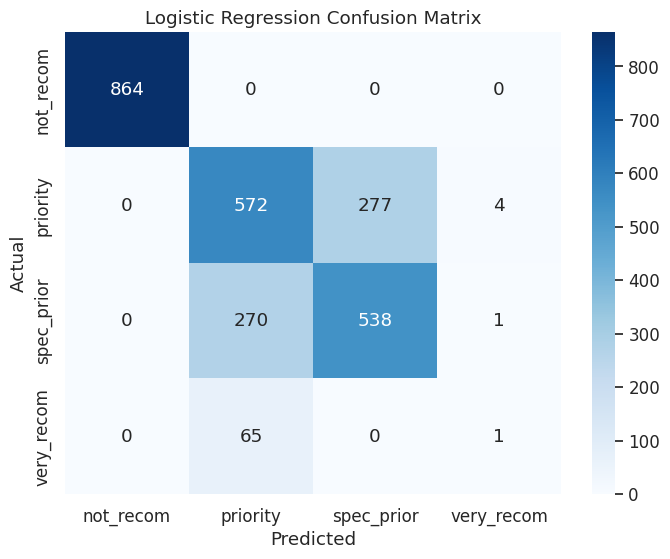

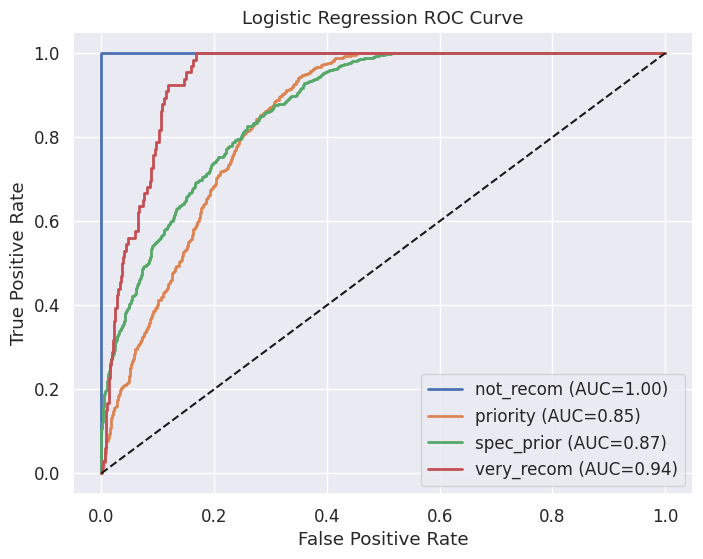



Decision Tree

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.99      0.99      0.99       853
   recommend       0.00      0.00      0.00         0
  spec_prior       0.99      0.99      0.99       809
  very_recom       1.00      0.97      0.98        66

    accuracy                           0.99      2592
   macro avg       0.80      0.79      0.79      2592
weighted avg       0.99      0.99      0.99      2592



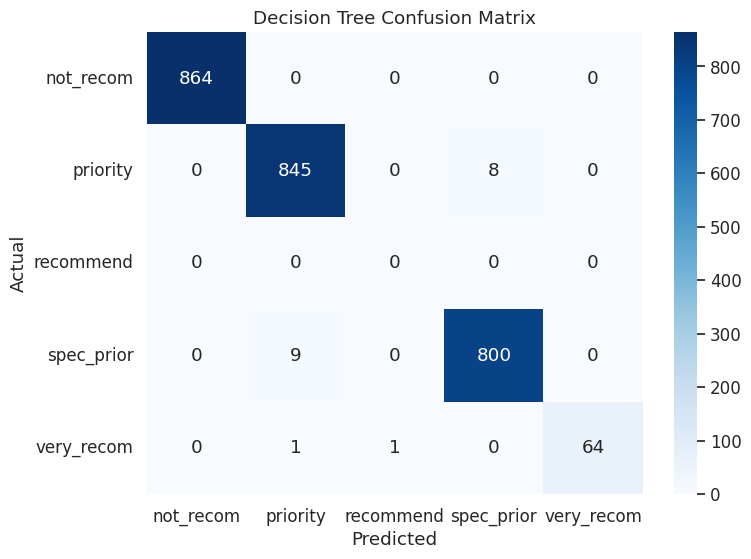

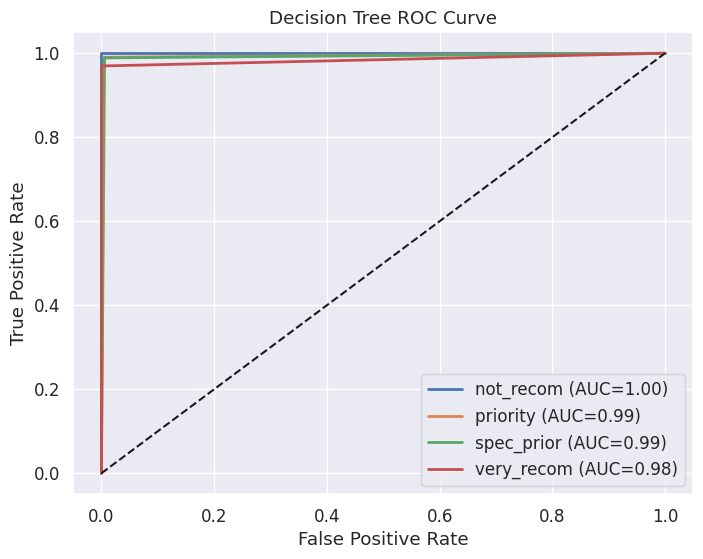



Random Forest

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.97      0.97      0.97       853
  spec_prior       0.97      0.99      0.98       809
  very_recom       1.00      0.74      0.85        66

    accuracy                           0.98      2592
   macro avg       0.99      0.93      0.95      2592
weighted avg       0.98      0.98      0.98      2592



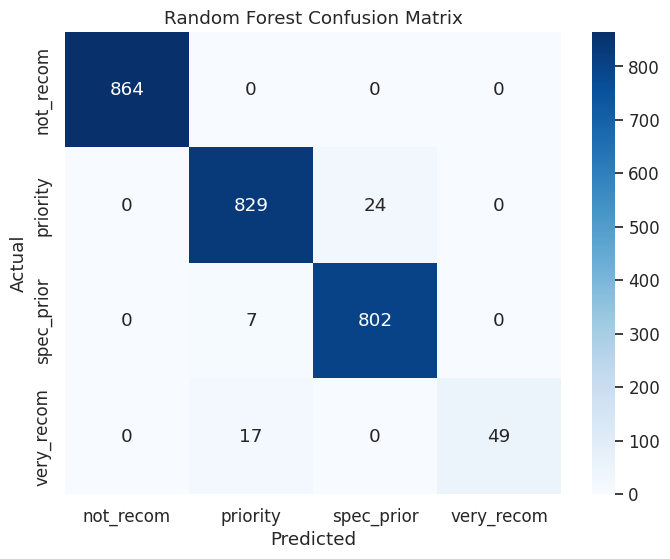

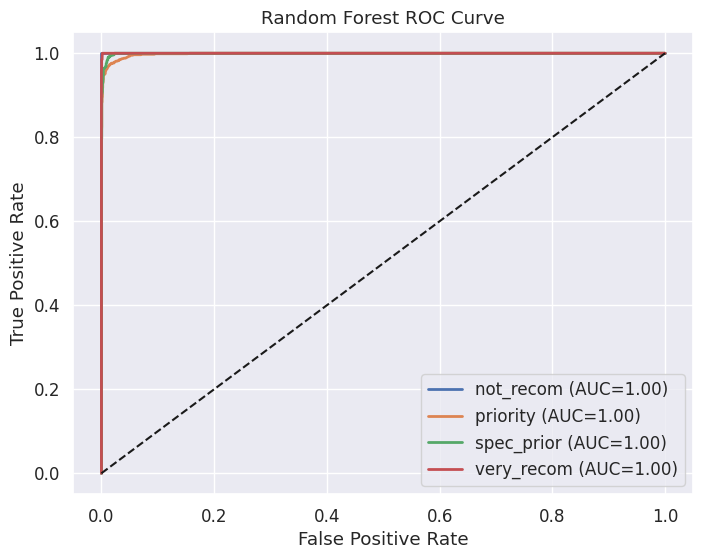



Gradient Boosting

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.97      0.98      0.97       853
   recommend       0.00      0.00      0.00         0
  spec_prior       0.98      1.00      0.99       809
  very_recom       1.00      0.64      0.78        66

    accuracy                           0.98      2592
   macro avg       0.79      0.72      0.75      2592
weighted avg       0.98      0.98      0.98      2592



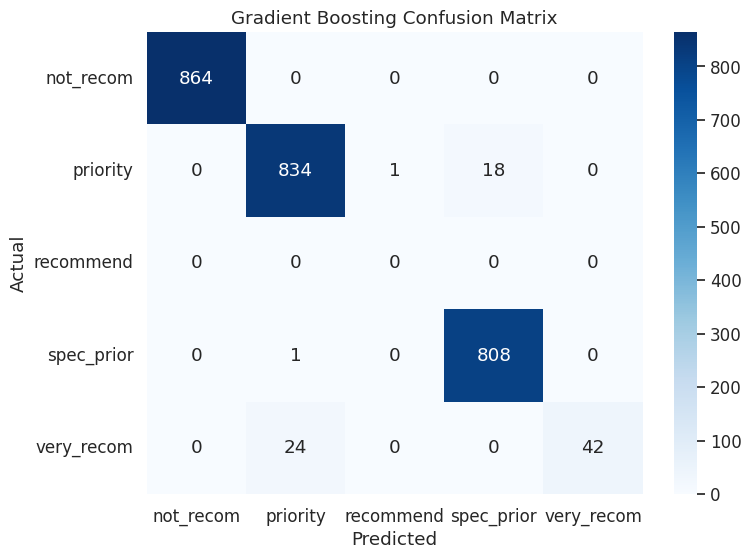

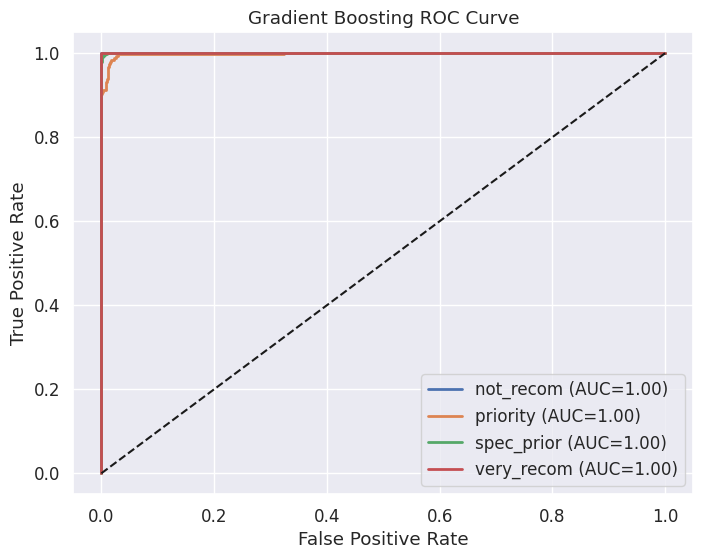



Extra Trees

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.96      0.96      0.96       853
  spec_prior       0.96      0.99      0.97       809
  very_recom       1.00      0.70      0.82        66

    accuracy                           0.98      2592
   macro avg       0.98      0.91      0.94      2592
weighted avg       0.98      0.98      0.98      2592



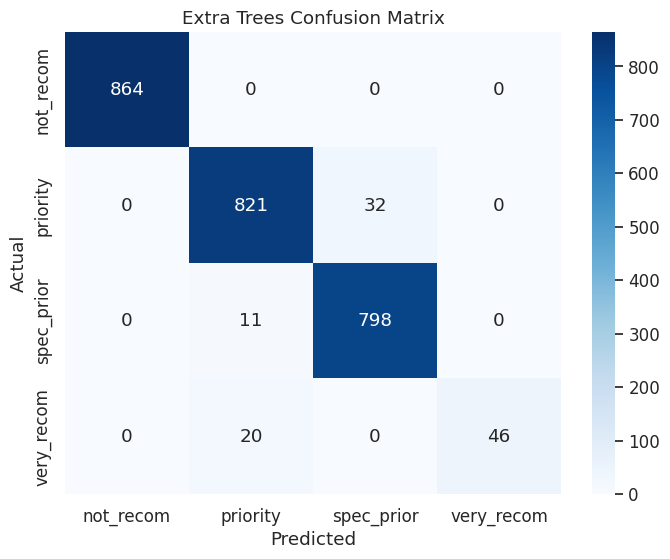

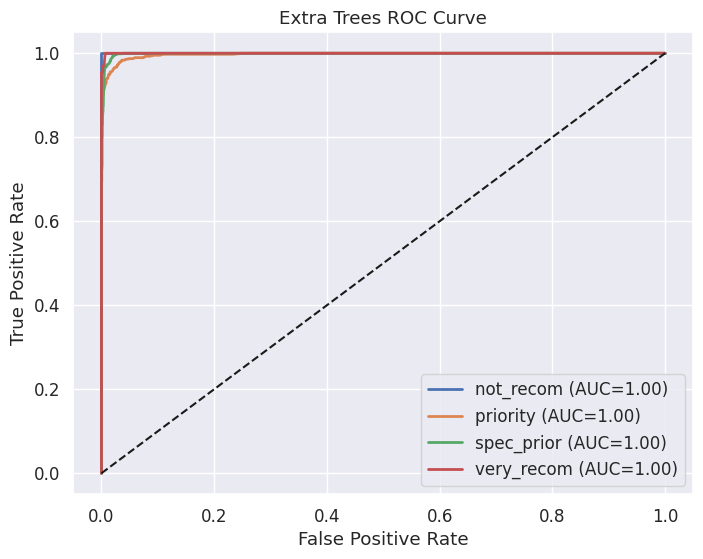



AdaBoost

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.73      0.90      0.81       853
  spec_prior       0.91      0.71      0.80       809
  very_recom       0.45      0.33      0.38        66

    accuracy                           0.86      2592
   macro avg       0.77      0.74      0.75      2592
weighted avg       0.87      0.86      0.86      2592



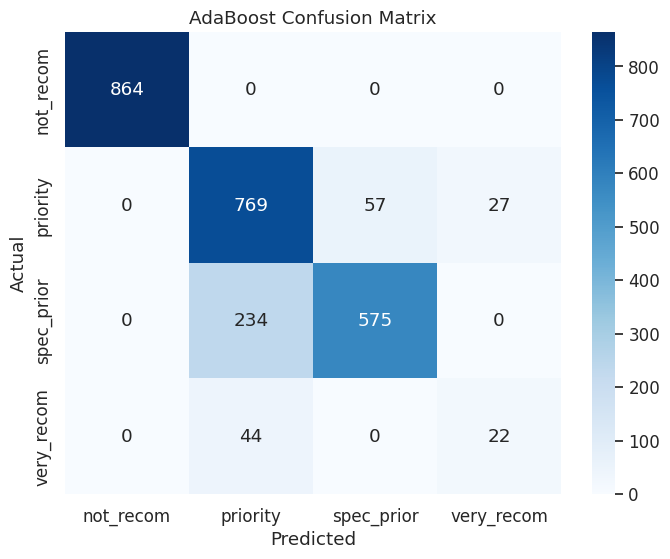

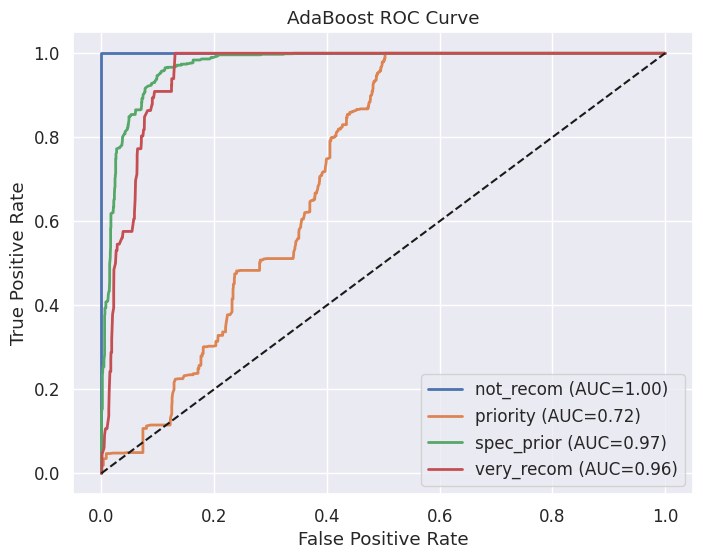



KNN

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.80      0.93      0.86       853
  spec_prior       0.94      0.79      0.86       809
  very_recom       0.73      0.68      0.70        66

    accuracy                           0.90      2592
   macro avg       0.87      0.85      0.86      2592
weighted avg       0.91      0.90      0.90      2592



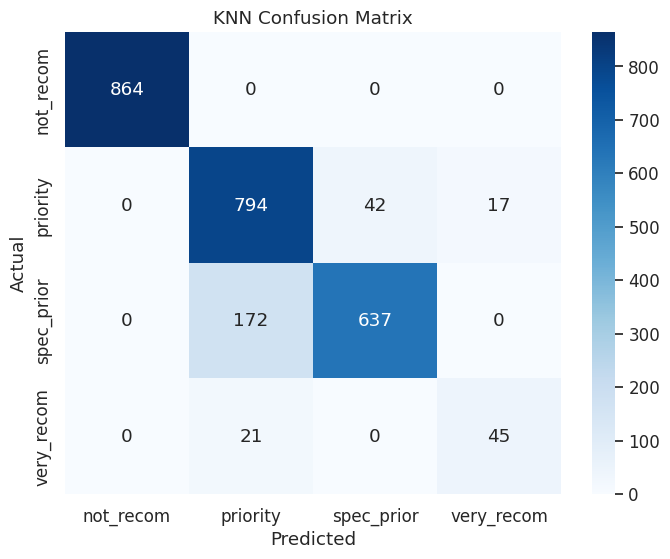

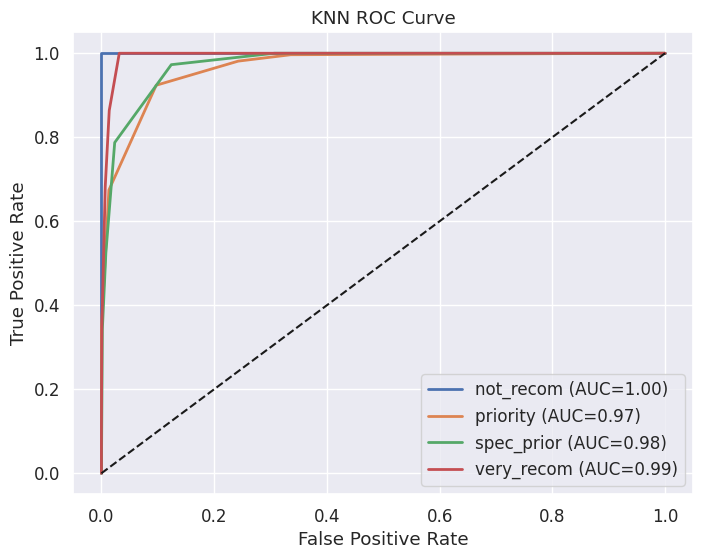



SVM

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.93      0.94      0.93       853
  spec_prior       0.94      0.98      0.96       809
  very_recom       1.00      0.35      0.52        66

    accuracy                           0.96      2592
   macro avg       0.97      0.82      0.85      2592
weighted avg       0.96      0.96      0.95      2592



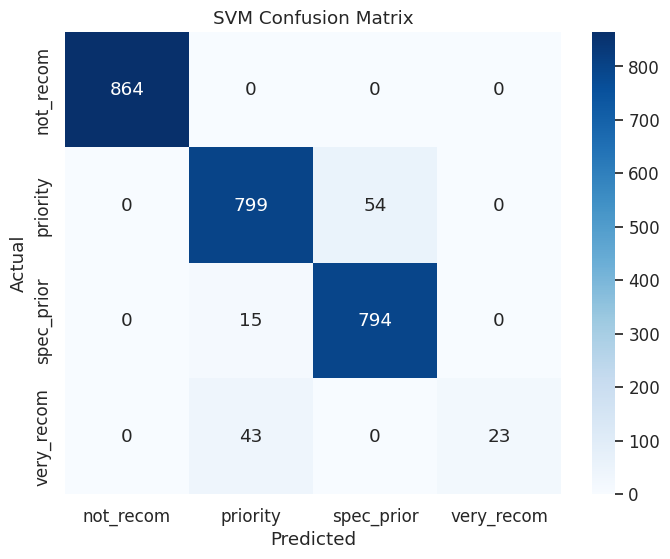

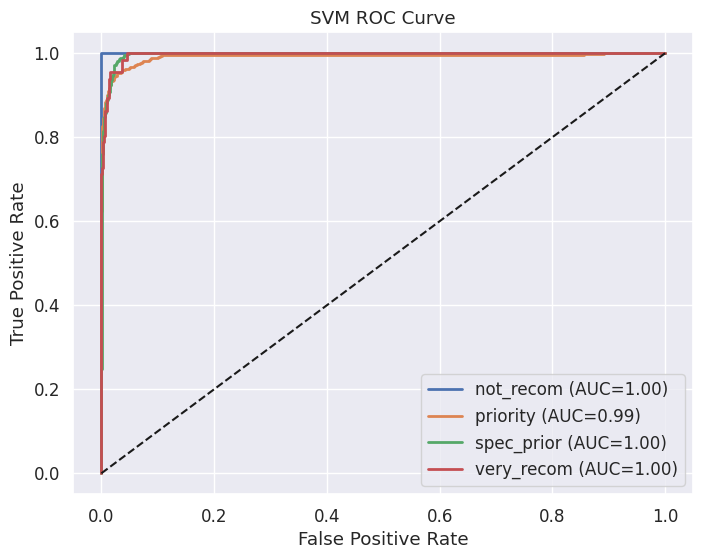



Naive Bayes

Classification Report

              precision    recall  f1-score   support

   not_recom       1.00      1.00      1.00       864
    priority       0.78      0.31      0.45       853
   recommend       0.00      0.00      0.00         0
  spec_prior       0.83      0.57      0.68       809
  very_recom       0.08      1.00      0.15        66

    accuracy                           0.64      2592
   macro avg       0.54      0.58      0.45      2592
weighted avg       0.85      0.64      0.70      2592



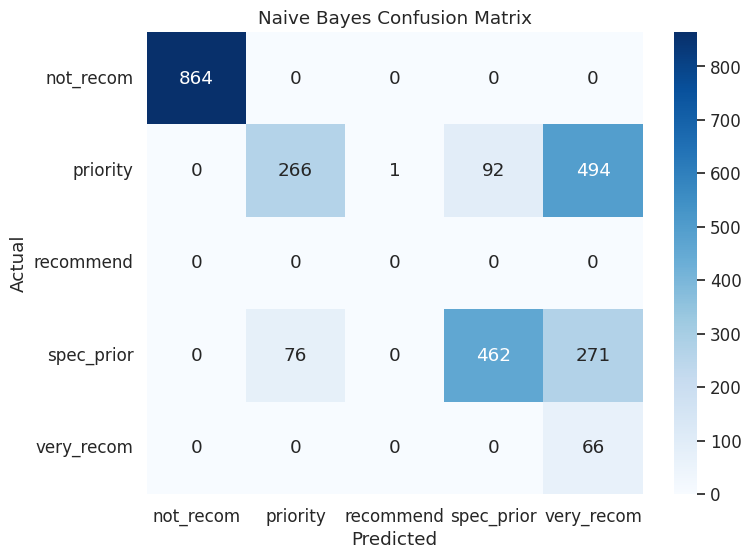

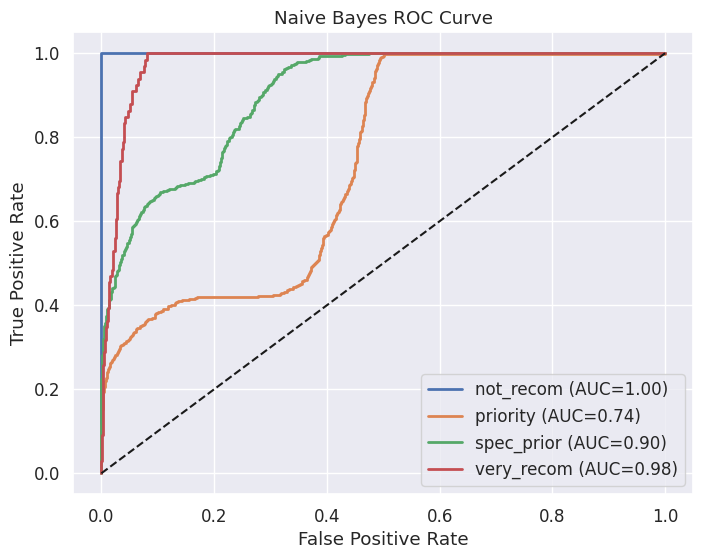



MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
1        Decision Tree  0.992670   0.993061  0.992670  0.992859
3    Gradient Boosting  0.983025   0.983621  0.983025  0.982257
2        Random Forest  0.981481   0.981672  0.981481  0.981059
4          Extra Trees  0.975694   0.975993  0.975694  0.975105
7                  SVM  0.956790   0.957853  0.956790  0.953146
6                  KNN  0.902778   0.909361  0.902778  0.902482
5             AdaBoost  0.860340   0.870440  0.860340  0.858550
0  Logistic Regression  0.761960   0.751151  0.761960  0.754744
8          Naive Bayes  0.639660   0.851597  0.639660  0.695175


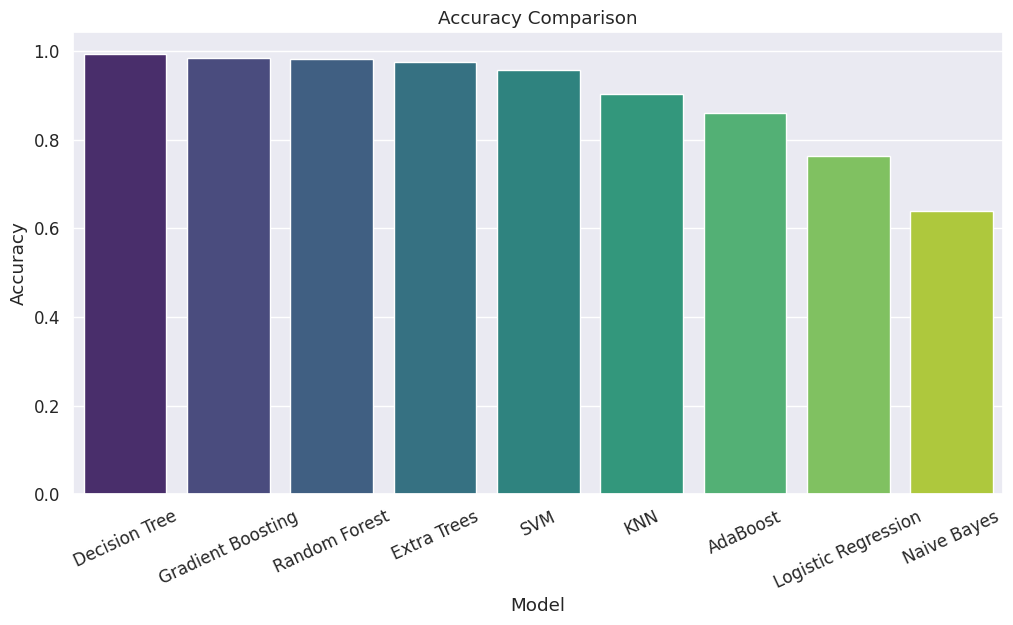

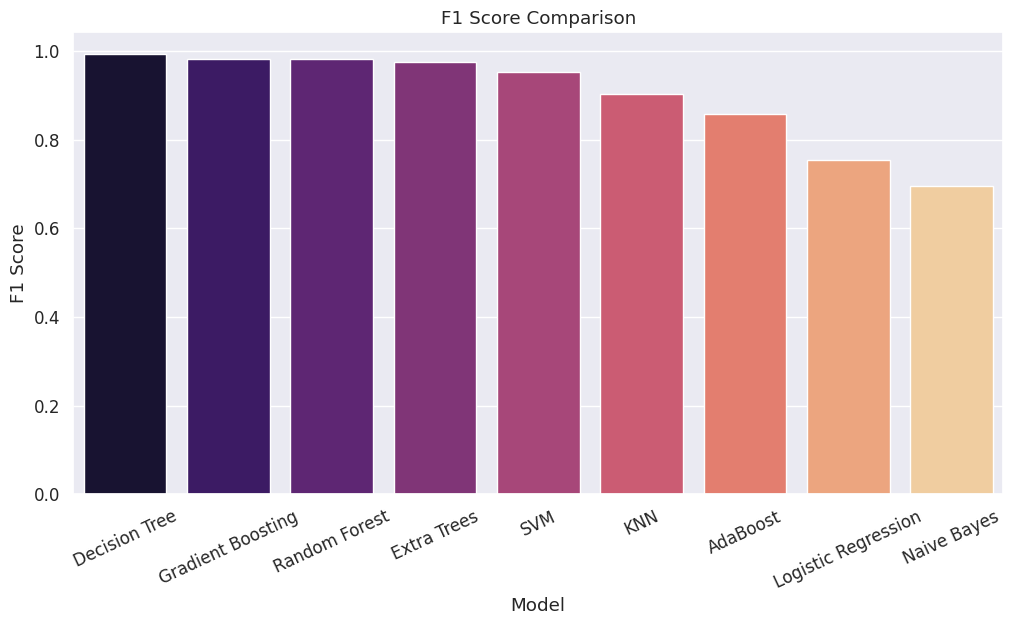

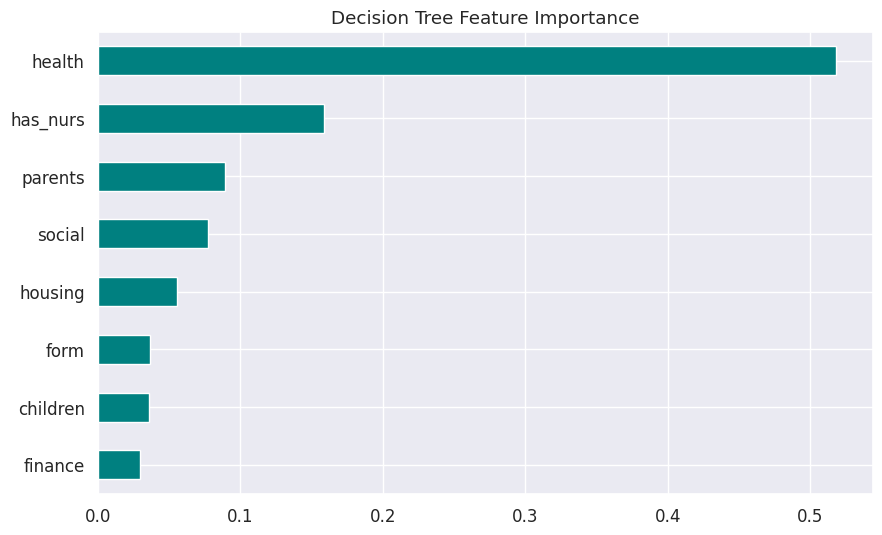

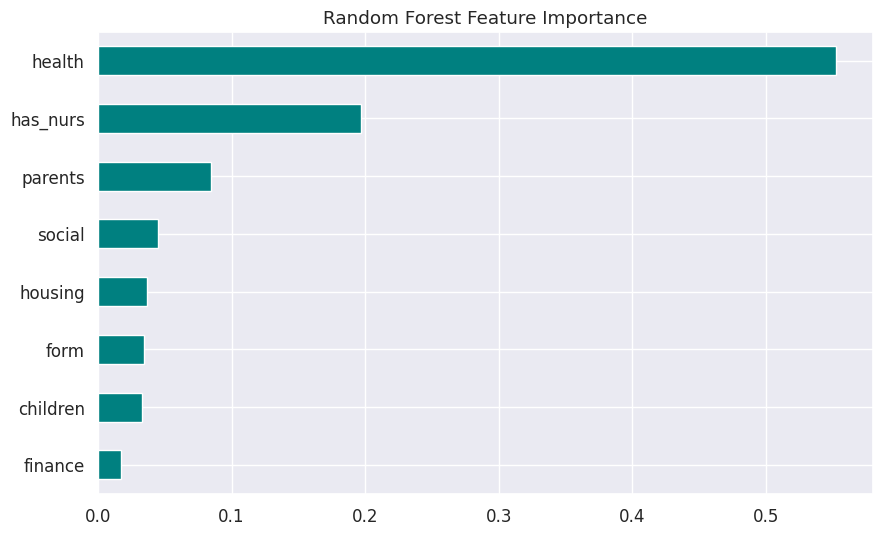

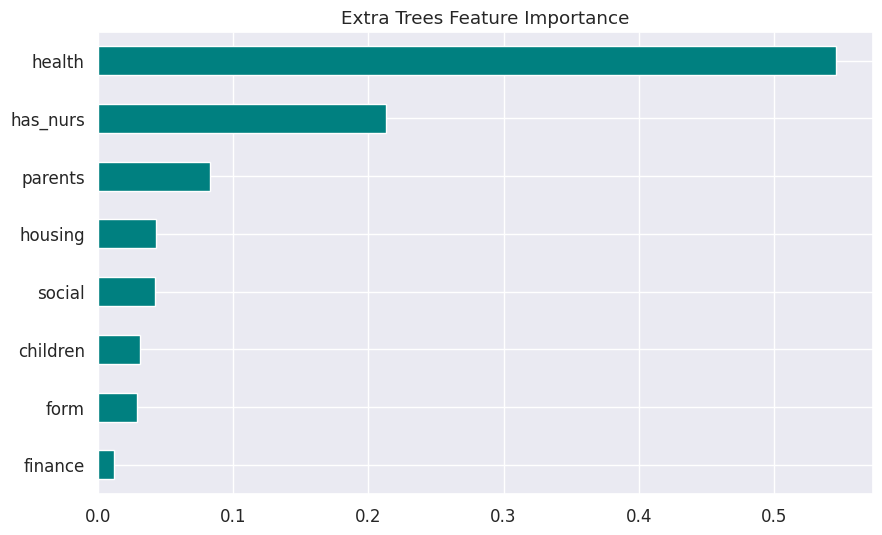



BEST MODEL
Model        Decision Tree
Accuracy           0.99267
Precision         0.993061
Recall             0.99267
F1 Score          0.992859
Name: 1, dtype: object

Best Model : Decision Tree
Accuracy   : 0.9927
Precision  : 0.9931
Recall     : 0.9927
F1 Score   : 0.9929

Results saved as Nursery_Model_Comparison.csv


MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [16]:
# ==========================================================
# PART 4 : EVALUATION, ROC CURVE & MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# ==========================================================
# EVALUATE ALL MODELS
# ==========================================================

n_classes = len(target_encoder.classes_)

for model_name, model in trained_models.items():

    print("\n")
    print("="*80)
    print(model_name)
    print("="*80)

    prediction = model.predict(X_test)

    labels = np.unique(np.concatenate([y_test, prediction]))

    # ------------------------------------------------------
    # CLASSIFICATION REPORT
    # ------------------------------------------------------

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            prediction,
            labels=labels,
            target_names=target_encoder.inverse_transform(labels),
            zero_division=0
        )
    )

    # ------------------------------------------------------
    # CONFUSION MATRIX
    # ------------------------------------------------------

    cm = confusion_matrix(
        y_test,
        prediction,
        labels=labels
    )

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_encoder.inverse_transform(labels),
        yticklabels=target_encoder.inverse_transform(labels)
    )

    plt.title(model_name + " Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ------------------------------------------------------
    # ROC CURVE
    # ------------------------------------------------------

    if hasattr(model, "predict_proba"):

        probs = model.predict_proba(X_test)

        y_bin = label_binarize(
            y_test,
            classes=np.arange(n_classes)
        )

        plt.figure(figsize=(8,6))

        for i in range(n_classes):

            if np.sum(y_bin[:, i]) == 0:
                continue

            fpr, tpr, _ = roc_curve(
                y_bin[:, i],
                probs[:, i]
            )

            roc_auc = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.2f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            "k--"
        )

        plt.title(model_name + " ROC Curve")

        plt.xlabel("False Positive Rate")

        plt.ylabel("True Positive Rate")

        plt.legend()

        plt.grid(True)

        plt.show()

# ==========================================================
# MODEL COMPARISON TABLE
# ==========================================================

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*80)
print("MODEL COMPARISON")
print("="*80)

print(results_df)

# ==========================================================
# ACCURACY GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.xticks(rotation=25)

plt.title("Accuracy Comparison")

plt.show()

# ==========================================================
# F1 SCORE GRAPH
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1 Score",
    palette="magma"
)

plt.xticks(rotation=25)

plt.title("F1 Score Comparison")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

feature_names = X.columns

tree_models = [
    "Decision Tree",
    "Random Forest",
    "Extra Trees"
]

for model_name in tree_models:

    if model_name in trained_models:

        model = trained_models[model_name]

        importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        )

        importance = importance.sort_values(
            ascending=False
        )

        plt.figure(figsize=(10,6))

        importance.head(10).plot(
            kind="barh",
            color="teal"
        )

        plt.title(model_name + " Feature Importance")

        plt.gca().invert_yaxis()

        plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print("\n")
print("="*80)
print("BEST MODEL")
print("="*80)

print(best_model)

print("\nBest Model :", best_model["Model"])
print("Accuracy   :", round(best_model["Accuracy"],4))
print("Precision  :", round(best_model["Precision"],4))
print("Recall     :", round(best_model["Recall"],4))
print("F1 Score   :", round(best_model["F1 Score"],4))

# ==========================================================
# SAVE RESULTS
# ==========================================================

results_df.to_csv(
    "Nursery_Model_Comparison.csv",
    index=False
)

print("\nResults saved as Nursery_Model_Comparison.csv")

print("\n")
print("="*80)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*80)

## Thanks........please Upvote